In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')



In [2]:
df_5to7 = pd.read_csv('data/accidents_2005_to_2007.csv', dtype={'LSOA_of_Accident_Location': str})
df_9to11 = pd.read_csv('data/accidents_2009_to_2011.csv', dtype={'LSOA_of_Accident_Location': str})
df_12to14 = pd.read_csv('data/accidents_2012_to_2014.csv', dtype={'LSOA_of_Accident_Location': str})

df_aadf = pd.read_csv('data/ukTrafficAADF.csv')


df_5to7.head(5)

,Accident_Index,Location_Easting_OSGR,Location_Northing_OSGR,Longitude,Latitude,Police_Force,Accident_Severity,Number_of_Vehicles,Number_of_Casualties,Date,...,Pedestrian_Crossing-Physical_Facilities,Light_Conditions,Weather_Conditions,Road_Surface_Conditions,Special_Conditions_at_Site,Carriageway_Hazards,Urban_or_Rural_Area,Did_Police_Officer_Attend_Scene_of_Accident,LSOA_of_Accident_Location,Year
0,200501BS00001,525680.0,178240.0,-0.191170,51.489096,1,2,1,1,04/01/2005,...,Zebra crossing,Daylight: Street light present,Raining without high winds,Wet/Damp,NaN,NaN,1,Yes,E01002849,2005
1,200501BS00002,524170.0,181650.0,-0.211708,51.520075,1,3,1,1,05/01/2005,...,Pedestrian phase at traffic signal junction,Darkness: Street lights present and lit,Fine without high winds,Dry,NaN,NaN,1,Yes,E01002909,2005
2,200501BS00003,524520.0,182240.0,-0.206458,51.525301,1,3,2,1,06/01/2005,...,No physical crossing within 50 meters,Darkness: Street lights present and lit,Fine without high winds,Dry,NaN,NaN,1,Yes,E01002857,2005
3,200501BS00004,526900.0,177530.0,-0.173862,51.482442,1,3,1,1,07/01/2005,...,No physical crossing within 50 meters,Daylight: Street light present,Fine without high winds,Dry,NaN,NaN,1,Yes,E01002840,2005
4,200501BS00005,528060.0,179040.0,-0.156618,51.495752,1,3,1,1,10/01/2005,...,No physical crossing within 50 meters,Darkness: Street lighting unknown,Fine without high winds,Wet/Damp,NaN,NaN,1,Yes,E01002863,2005


In [3]:
check = df_5to7.columns.equals(df_9to11.columns) and df_9to11.columns.equals(df_12to14.columns)

print(f"All files have the same features: {check}")

All files have the same features: True


In [4]:
df_total = pd.concat([df_5to7, df_9to11, df_12to14], ignore_index= True)

In [5]:
df_total.info()

<class 'pandas.DataFrame'>
RangeIndex: 1504150 entries, 0 to 1504149
Data columns (total 33 columns):
 #   Column                                       Non-Null Count    Dtype  
---  ------                                       --------------    -----  
 0   Accident_Index                               1504150 non-null  str    
 1   Location_Easting_OSGR                        1504049 non-null  float64
 2   Location_Northing_OSGR                       1504049 non-null  float64
 3   Longitude                                    1504049 non-null  float64
 4   Latitude                                     1504049 non-null  float64
 5   Police_Force                                 1504150 non-null  int64  
 6   Accident_Severity                            1504150 non-null  int64  
 7   Number_of_Vehicles                           1504150 non-null  int64  
 8   Number_of_Casualties                         1504150 non-null  int64  
 9   Date                                         1504150 non-

In [6]:
df_total.isnull().sum()

Accident_Index                                       0
Location_Easting_OSGR                              101
Location_Northing_OSGR                             101
Longitude                                          101
Latitude                                           101
Police_Force                                         0
Accident_Severity                                    0
Number_of_Vehicles                                   0
Number_of_Casualties                                 0
Date                                                 0
Day_of_Week                                          0
Time                                               117
Local_Authority_(District)                           0
Local_Authority_(Highway)                            0
1st_Road_Class                                       0
1st_Road_Number                                      0
Road_Type                                            0
Speed_limit                                          0
Junction_D

We have many columns with **missing values**. I will check on each of them to see if the `NaN` are representing `None` or if they are missing



In [7]:
df = df_total.drop(columns= ['Junction_Detail'])

In [8]:
feat_to_check = ['Junction_Control', 'Pedestrian_Crossing-Human_Control',
                  'Pedestrian_Crossing-Physical_Facilities', 
                  'Weather_Conditions', 'Road_Surface_Conditions',
                  'Special_Conditions_at_Site', 'Carriageway_Hazards',
                  'Did_Police_Officer_Attend_Scene_of_Accident',
                  'LSOA_of_Accident_Location'
                ]


for ele in feat_to_check:
    print('\n' + ('=' * 40))
    print(f"Feature: {ele}")
    print('-' * 40)
    print(df[ele].value_counts(dropna=False))



Feature: Junction_Control
----------------------------------------
Junction_Control
Giveway or uncontrolled     733940
NaN                         602835
Automatic traffic signal    155717
Stop Sign                     9179
Authorised person             2479
Name: count, dtype: int64

Feature: Pedestrian_Crossing-Human_Control
----------------------------------------
Pedestrian_Crossing-Human_Control
None within 50 metres                 1495269
Control by other authorised person       5220
Control by school crossing patrol        3644
NaN                                        17
Name: count, dtype: int64

Feature: Pedestrian_Crossing-Physical_Facilities
----------------------------------------
Pedestrian_Crossing-Physical_Facilities
No physical crossing within 50 meters          1252571
Pedestrian phase at traffic signal junction     100248
non-junction pedestrian crossing                 79231
Zebra crossing                                   40106
Central refuge                    

Checking on the *location* features, let see if all four location-related columns have missing values in the exact same rows

In [9]:
loc_cols = ['Location_Easting_OSGR', 'Location_Northing_OSGR', 'Longitude', 'Latitude']

null_mask = df[loc_cols].isnull()
is_same = df[loc_cols].isnull().all(axis=1).eq(df[loc_cols].isnull().any(axis=1)).all()

print(f"Are all location missing values in the same rows? {is_same}")

Are all location missing values in the same rows? True


Good based on the analytics and the findings, we can set up the imputation as:

- `Junction_Control`, `Special_Conditions_at_Site`, `Carriageway_Hazards`: NaN has high proportion. They represents *None* in this case
  
- `Pedestrian_Crossing-Human_Control`, `Pedestrian_Crossing-Physical_Facilities`, `Weather_Conditions`, `Road_Surface_Conditions`, `Time`, `Latitude` has minor proportion of NaN values **(< 1%)**, we will just drop them

- `Did_Police_Officer_Attend_Scene_of_Accident`, `LSOA_of_Accident_Location` has a bit more, so we will impute them as **unknown**

In [10]:
fill_none_feat = [
    'Junction_Control', 'Special_Conditions_at_Site',
    'Carriageway_Hazards',
]

drop_na_feat = [
    'Pedestrian_Crossing-Human_Control', 'Pedestrian_Crossing-Physical_Facilities',
    'Weather_Conditions', 'Road_Surface_Conditions', 'Time', 'Latitude'
]

fill_unknown_feat = [
    'Did_Police_Officer_Attend_Scene_of_Accident',
    'LSOA_of_Accident_Location'
]

In [11]:
for ele in fill_none_feat:
    df[ele] = df[ele].fillna('None')

df = df.dropna(subset=drop_na_feat)

for ele in fill_unknown_feat:
    df[ele] = df[ele].fillna('Unknown')

In [12]:
df.isnull().sum()

Accident_Index                                 0
Location_Easting_OSGR                          0
Location_Northing_OSGR                         0
Longitude                                      0
Latitude                                       0
Police_Force                                   0
Accident_Severity                              0
Number_of_Vehicles                             0
Number_of_Casualties                           0
Date                                           0
Day_of_Week                                    0
Time                                           0
Local_Authority_(District)                     0
Local_Authority_(Highway)                      0
1st_Road_Class                                 0
1st_Road_Number                                0
Road_Type                                      0
Speed_limit                                    0
Junction_Control                               0
2nd_Road_Class                                 0
2nd_Road_Number     

In [13]:
df.info()

<class 'pandas.DataFrame'>
Index: 1501819 entries, 0 to 1504149
Data columns (total 32 columns):
 #   Column                                       Non-Null Count    Dtype  
---  ------                                       --------------    -----  
 0   Accident_Index                               1501819 non-null  str    
 1   Location_Easting_OSGR                        1501819 non-null  float64
 2   Location_Northing_OSGR                       1501819 non-null  float64
 3   Longitude                                    1501819 non-null  float64
 4   Latitude                                     1501819 non-null  float64
 5   Police_Force                                 1501819 non-null  int64  
 6   Accident_Severity                            1501819 non-null  int64  
 7   Number_of_Vehicles                           1501819 non-null  int64  
 8   Number_of_Casualties                         1501819 non-null  int64  
 9   Date                                         1501819 non-null 

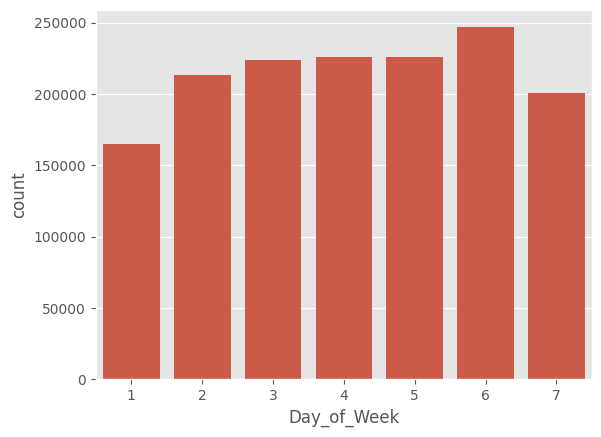

In [14]:
sns.countplot(df, x= 'Day_of_Week')
plt.show()

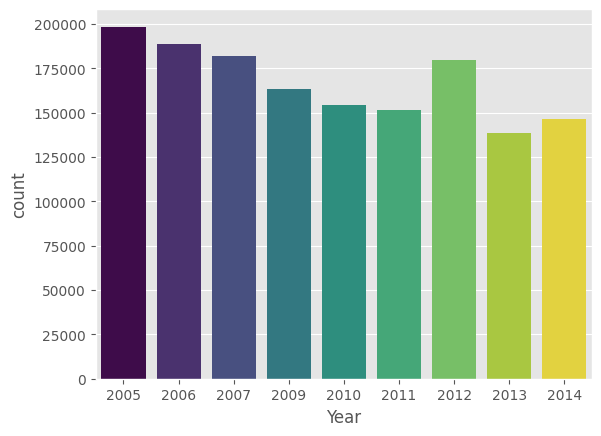

In [15]:

sns.countplot(data=df, x='Year', hue='Year', palette='viridis', legend=False)

plt.show()

In [16]:
df['Time'] = pd.to_datetime(df['Time'])
df['Hour'] = df['Time'].dt.hour

C:\Users\ducth\AppData\Local\Temp\ipykernel_3052\113868986.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Time'] = pd.to_datetime(df['Time'])


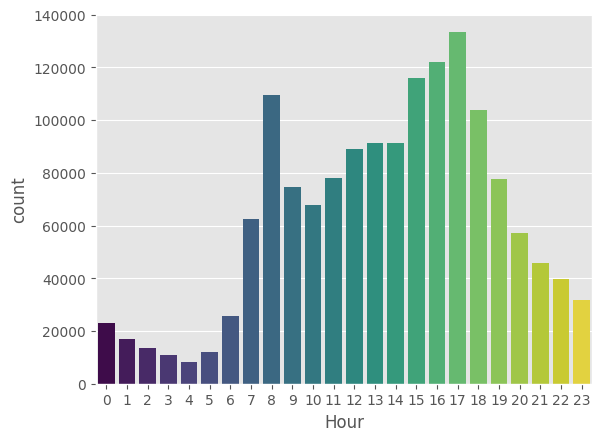

In [17]:
sns.countplot(data=df, x='Hour', hue='Hour', palette='viridis', legend=False)
plt.show()

In [18]:
df['LSOA_of_Accident_Location'].unique()

<ArrowStringArray>
['E01002849', 'E01002909', 'E01002857', 'E01002840', 'E01002863', 'E01002832',
 'E01002875', 'E01002889', 'E01002900', 'E01002835',
 ...
 'E01032691', 'E01032706', 'E01032712', 'E01032708', 'W01001596', 'W01001919',
 'W01001944', 'W01001948', 'W01001914', 'W01001921']
Length: 35453, dtype: str

In [19]:
import geopandas as gpd
from shapely.geometry import Point

districts = gpd.read_file('Data/lsoa.geojson')


geometry = [Point(xy) for xy in zip(df['Longitude'], df['Latitude'])]
gdf_accidents = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326")

districts = districts.to_crs("EPSG:4326")

df_mapped = gpd.sjoin(gdf_accidents, districts, how="left", predicate="within")

print(df_mapped.head())

  Accident_Index  Location_Easting_OSGR  Location_Northing_OSGR  Longitude  \
0  200501BS00001               525680.0                178240.0  -0.191170   
1  200501BS00002               524170.0                181650.0  -0.211708   
2  200501BS00003               524520.0                182240.0  -0.206458   
3  200501BS00004               526900.0                177530.0  -0.173862   
4  200501BS00005               528060.0                179040.0  -0.156618   

    Latitude  Police_Force  Accident_Severity  Number_of_Vehicles  \
0  51.489096             1                  2                   1   
1  51.520075             1                  3                   1   
2  51.525301             1                  3                   2   
3  51.482442             1                  3                   1   
4  51.495752             1                  3                   1   

   Number_of_Casualties        Date  ...  objectid    lad16cd  \
0                     1  04/01/2005  ...     313.0 

In [20]:
df_mapped.isnull().sum()


Accident_Index                                    0
Location_Easting_OSGR                             0
Location_Northing_OSGR                            0
Longitude                                         0
Latitude                                          0
Police_Force                                      0
Accident_Severity                                 0
Number_of_Vehicles                                0
Number_of_Casualties                              0
Date                                              0
Day_of_Week                                       0
Time                                              0
Local_Authority_(District)                        0
Local_Authority_(Highway)                         0
1st_Road_Class                                    0
1st_Road_Number                                   0
Road_Type                                         0
Speed_limit                                       0
Junction_Control                                  0
2nd_Road_Cla

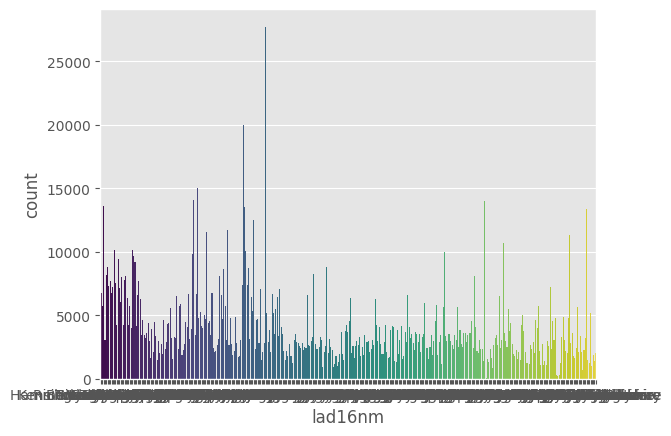

In [21]:
df_mapped = df_mapped.dropna()
sns.countplot(df_mapped, x = 'lad16nm', hue = 'lad16nm', palette= 'viridis', legend = False)
plt.show()

In [22]:
df = df_mapped
top_20_districts = df['lad16nm'].value_counts().nlargest(20).index

df_top20 = df[df['lad16nm'].isin(top_20_districts)]

bot_20_districts = df['lad16nm'].value_counts().nsmallest(20).index

df_bot20 = df[df['lad16nm'].isin(bot_20_districts)]



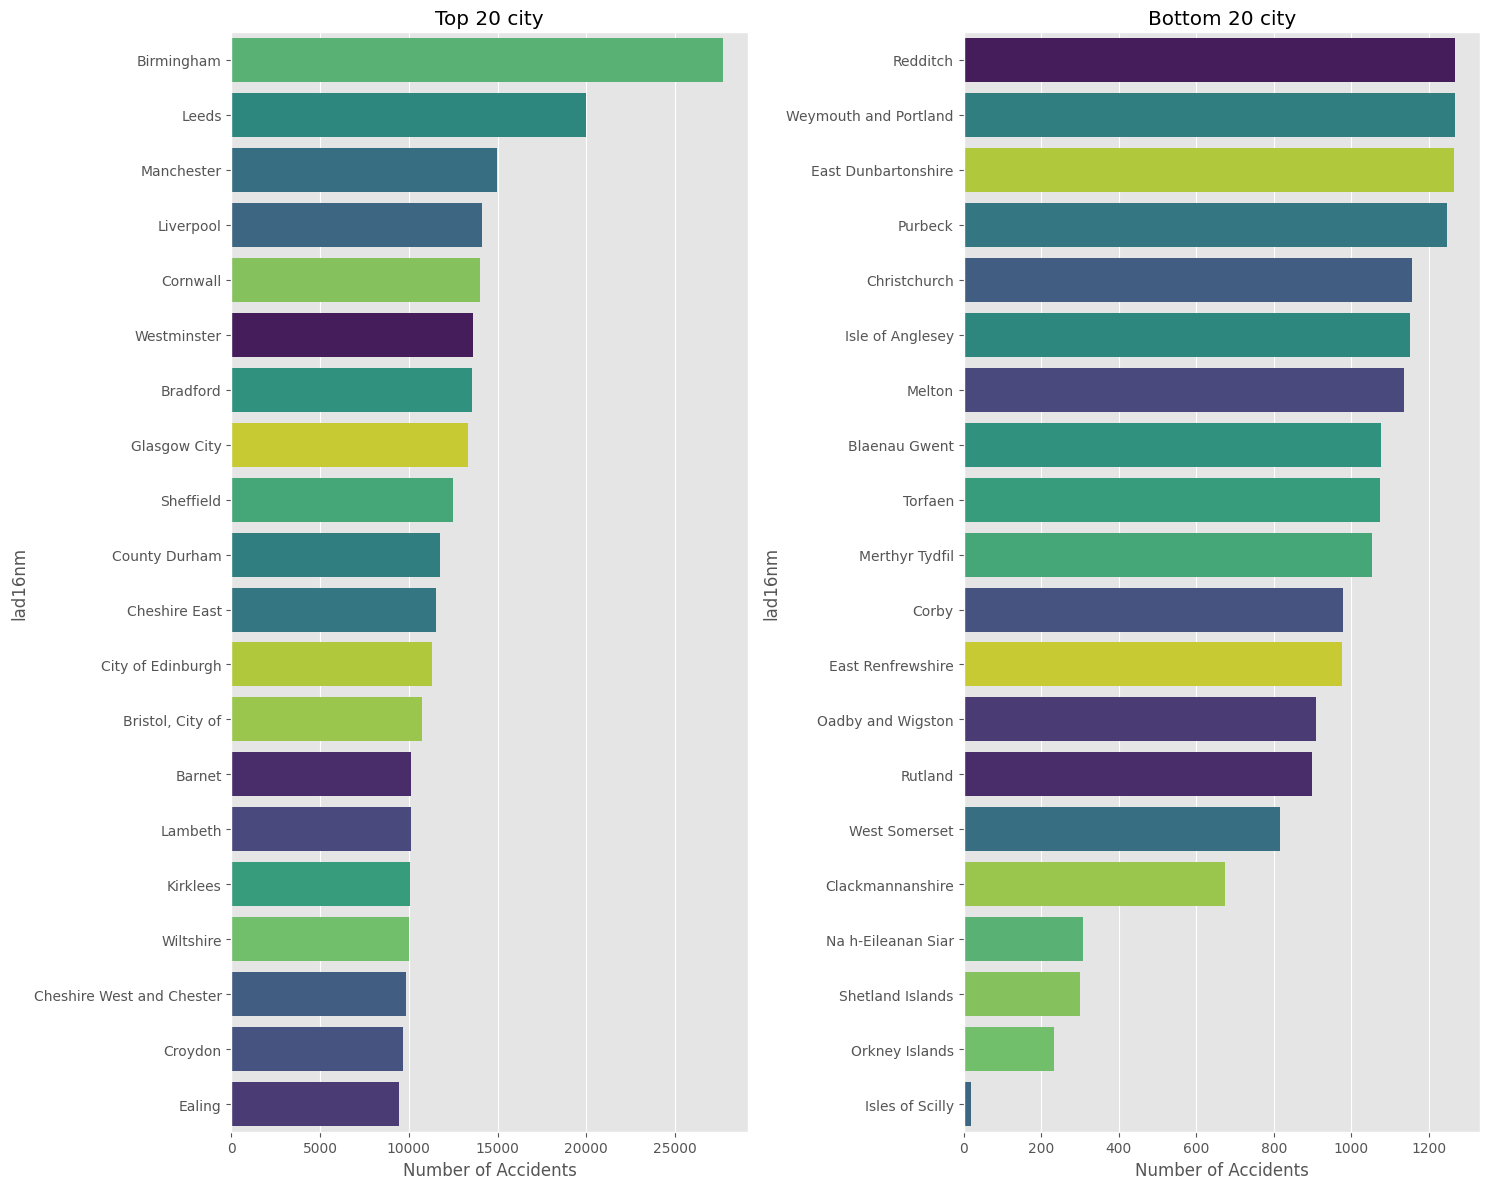

In [23]:
plt.figure(figsize=(15, 12))
plt.subplot(1, 2, 1)
sns.countplot(data=df_top20, y='lad16nm', hue = 'lad16nm', 
              order=top_20_districts, palette='viridis', legend= False)

plt.xlabel('Number of Accidents')
plt.title("Top 20 city")
plt.subplot(1, 2, 2)
sns.countplot(data=df_bot20, y='lad16nm', hue='lad16nm',
              order=bot_20_districts[::-1],
              palette='viridis', legend=False)

plt.xlabel('Number of Accidents')
plt.title("Bottom 20 city")
plt.tight_layout()
plt.show()

In [24]:
import reverse_geocoder as rg

# Batch lookup - much faster than row-by-row
coords = list(zip(df['Latitude'], df['Longitude']))
results = rg.search(coords) 

df['region'] = [r['admin2'] for r in results]
print(df['region'].value_counts())

Loading formatted geocoded file...
region
Greater London      228148
Kent                 45522
Surrey               37677
Lancashire           36426
Essex                34049
                     ...  
Clackmannanshire       747
Eilean Siar            321
Shetland Islands       301
Orkney Islands         234
Isles of Scilly         19
Name: count, Length: 174, dtype: int64


In [25]:
df['greater_region'] = [r['admin1'] for r in results]


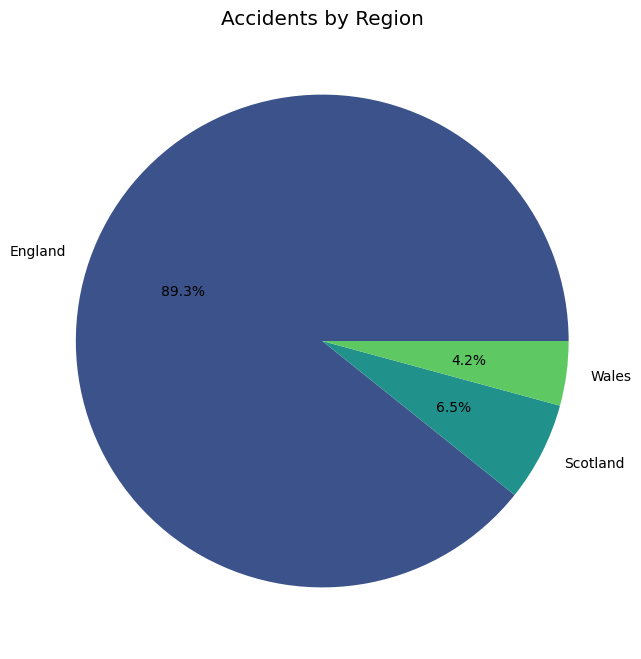

In [26]:
df['greater_region'].value_counts().plot.pie(
    autopct='%1.1f%%',
    figsize=(8, 8),
    colors=sns.color_palette('viridis', df['greater_region'].nunique())
)
plt.ylabel('')
plt.title('Accidents by Region')
plt.show()

In [27]:
df.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 1500408 entries, 0 to 1504149
Data columns (total 47 columns):
 #   Column                                       Non-Null Count    Dtype         
---  ------                                       --------------    -----         
 0   Accident_Index                               1500408 non-null  str           
 1   Location_Easting_OSGR                        1500408 non-null  float64       
 2   Location_Northing_OSGR                       1500408 non-null  float64       
 3   Longitude                                    1500408 non-null  float64       
 4   Latitude                                     1500408 non-null  float64       
 5   Police_Force                                 1500408 non-null  int64         
 6   Accident_Severity                            1500408 non-null  int64         
 7   Number_of_Vehicles                           1500408 non-null  int64         
 8   Number_of_Casualties                         1500

In [28]:
region_lookup = pd.read_csv('Data/lad_to_region_en.csv')
region_lookup.info()

<class 'pandas.DataFrame'>
RangeIndex: 326 entries, 0 to 325
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   LAD16CD  326 non-null    str  
 1   LAD16NM  326 non-null    str  
 2   RGN16CD  326 non-null    str  
 3   RGN16NM  326 non-null    str  
 4   FID      326 non-null    int64
dtypes: int64(1), str(4)
memory usage: 25.8 KB


In [29]:
region_lookup = region_lookup[['LAD16CD', 'RGN16NM']].drop_duplicates()

df = df.merge(
    region_lookup,
    left_on='lad16cd',
    right_on='LAD16CD',
    how='left'
)

print(df['RGN16NM'].value_counts())
print(f"\nTotal regions: {df['RGN16NM'].nunique()}")


RGN16NM
London                      230221
South East                  222855
North West                  183201
East of England             140206
Yorkshire and The Humber    135112
West Midlands               131699
South West                  123477
East Midlands               111722
North East                   60625
Name: count, dtype: int64

Total regions: 9


In [30]:
df.isnull().sum()

Accident_Index                                      0
Location_Easting_OSGR                               0
Location_Northing_OSGR                              0
Longitude                                           0
Latitude                                            0
Police_Force                                        0
Accident_Severity                                   0
Number_of_Vehicles                                  0
Number_of_Casualties                                0
Date                                                0
Day_of_Week                                         0
Time                                                0
Local_Authority_(District)                          0
Local_Authority_(Highway)                           0
1st_Road_Class                                      0
1st_Road_Number                                     0
Road_Type                                           0
Speed_limit                                         0
Junction_Control            

In [31]:
missing_mask = df['RGN16NM'].isna()
print(df[missing_mask]['lad16cd'].str[:3].value_counts())

lad16cd
S12    97554
W06    63736
Name: count, dtype: int64


In [32]:
df['RGN16NM'] = df['RGN16NM'].fillna(df['greater_region'])

# Sanity check - should be 0
print(df['RGN16NM'].isna().sum())

0


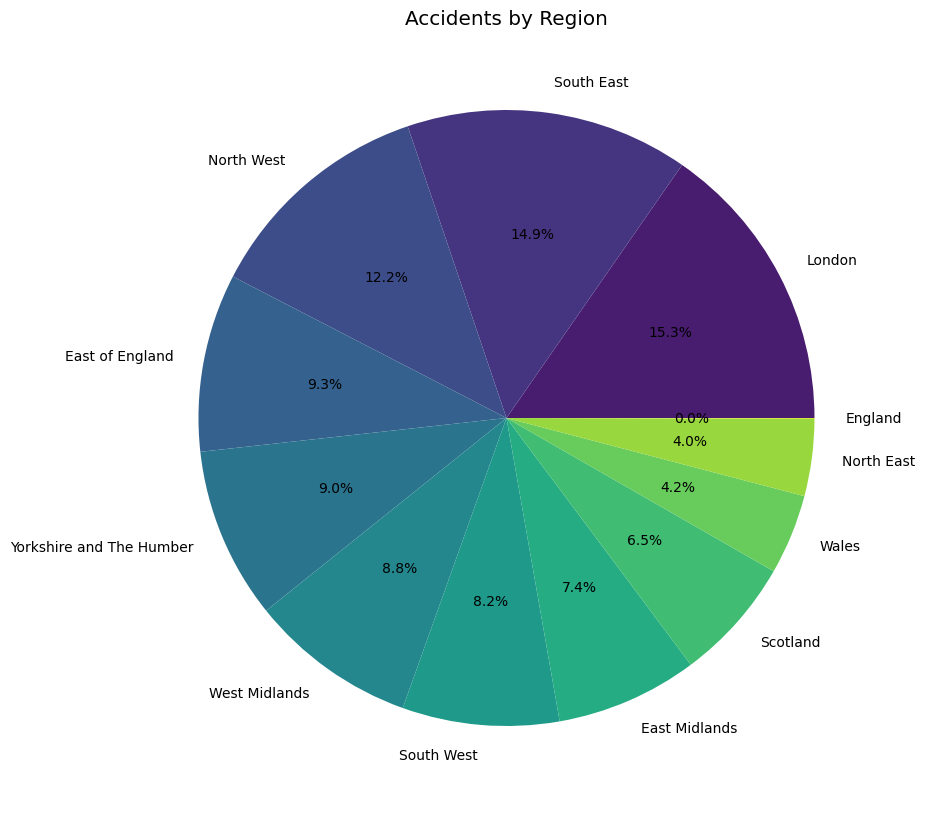

In [33]:
region_counts = df['RGN16NM'].value_counts()

plt.figure(figsize=(10, 10))
plt.pie(
    region_counts,
    labels=region_counts.index,
    autopct='%1.1f%%',
    colors=sns.color_palette('viridis', len(region_counts))
)
plt.title('Accidents by Region')
plt.show()

Geojson for regions: [Kaggle](https://www.kaggle.com/datasets/dorianlazar/uk-regions-geojson)

In [43]:
regions_geo = gpd.read_file('Data/uk_regions.geojson')
print(regions_geo.columns.tolist())
print(regions_geo.shape)
print(regions_geo['rgn19nm'].unique())  # adjust col name after seeing columns

['objectid', 'rgn19cd', 'rgn19nm', 'ctry19nmw', 'bng_e', 'bng_n', 'long', 'lat', 'st_areashape', 'st_lengthshape', 'geometry']
(12, 11)
<ArrowStringArray>
[              'North East',               'North West',
 'Yorkshire and the Humber',            'East Midlands',
            'West Midlands',                     'East',
                   'London',               'South East',
               'South West',         'Northern Ireland',
                 'Scotland',                    'Wales']
Length: 12, dtype: str


In [44]:
regions_geo['rgn19nm'] = regions_geo['rgn19nm'].replace({
    'East': 'East of England',
    'Yorkshire and the Humber': 'Yorkshire and The Humber'
})

In [46]:
region_counts = df['RGN16NM'].value_counts().reset_index()
region_counts.columns = ['RGN16NM', 'accident_count']

regions_geo = regions_geo.merge(
    region_counts,
    left_on='rgn19nm',
    right_on='RGN16NM',
    how='left'
)

# Sanity check - should be no NaN in accident_count
print(regions_geo[['rgn19nm', 'accident_count']])

                     rgn19nm  accident_count
0                 North East         60625.0
1                 North West        183201.0
2   Yorkshire and The Humber        135112.0
3              East Midlands        111722.0
4              West Midlands        131699.0
5            East of England        140206.0
6                     London        230221.0
7                 South East        222855.0
8                 South West        123477.0
9           Northern Ireland             NaN
10                  Scotland         97548.0
11                     Wales         63097.0


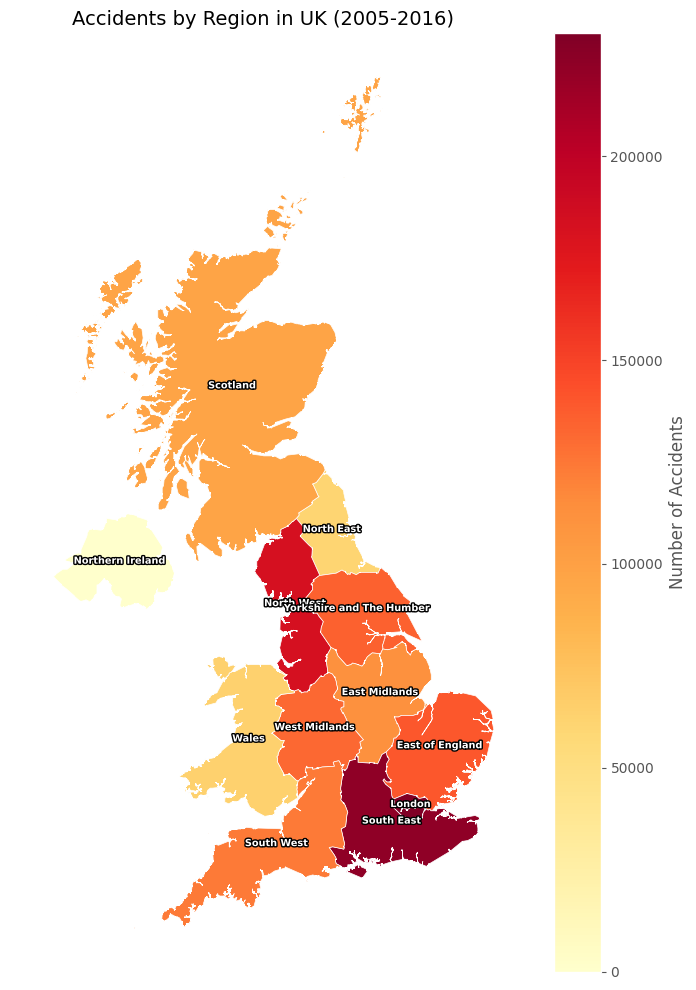

In [ ]:
from matplotlib.patheffects import withStroke

fig, ax = plt.subplots(1, 1, figsize=(8, 10))
regions_geo.plot(
    column='accident_count',
    ax=ax,
    legend=True,
    cmap='YlOrRd',
    edgecolor='white',
    linewidth=0.5,
    vmin=0,                                   # anchor 0 to the bottom of the scale
    vmax=regions_geo['accident_count'].max(),
    legend_kwds={'label': 'Number of Accidents'}
)

# Labels with outline effect for visibility
for _, row in regions_geo.iterrows():
    centroid = row['geometry'].centroid
    ax.annotate(
        row['rgn19nm'],
        xy=(centroid.x, centroid.y),
        ha='center', fontsize=7, fontweight='bold', color='white',
        path_effects=[withStroke(linewidth=2, foreground='black')]  # outline
    )

ax.set_title('Accidents by Region in UK (2005-2015)', fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.show()

In [55]:
df.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1500408 entries, 0 to 1500407
Data columns (total 49 columns):
 #   Column                                       Non-Null Count    Dtype         
---  ------                                       --------------    -----         
 0   Accident_Index                               1500408 non-null  str           
 1   Location_Easting_OSGR                        1500408 non-null  float64       
 2   Location_Northing_OSGR                       1500408 non-null  float64       
 3   Longitude                                    1500408 non-null  float64       
 4   Latitude                                     1500408 non-null  float64       
 5   Police_Force                                 1500408 non-null  int64         
 6   Accident_Severity                            1500408 non-null  int64         
 7   Number_of_Vehicles                           1500408 non-null  int64         
 8   Number_of_Casualties                        

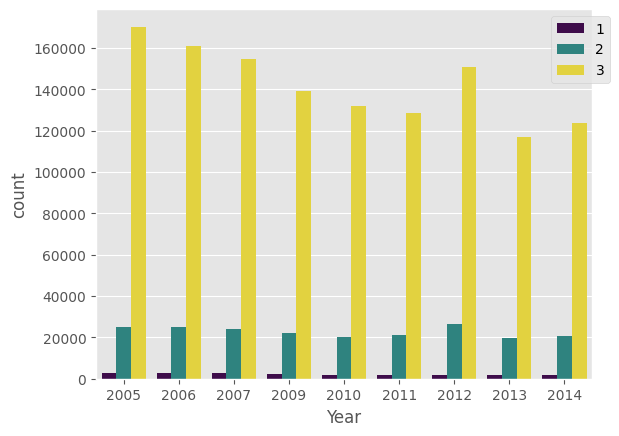

In [69]:
sns.countplot(df, hue = 'Accident_Severity', x = 'Year', palette= 'viridis')
plt.legend(bbox_to_anchor = [1.05, 1])
plt.show()

In [ ]:
df['Accident_Severity'] = df['Accident_Severity'].map({1: 'Fatal', 2: 'Serious', 3: 'Slight'})


C:\Users\ducth\AppData\Local\Temp\ipykernel_3052\3668620890.py:14: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.countplot(
C:\Users\ducth\AppData\Local\Temp\ipykernel_3052\3668620890.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Severity', loc='upper right')
C:\Users\ducth\AppData\Local\Temp\ipykernel_3052\3668620890.py:14: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.countplot(
C:\Users\ducth\AppData\Local\Temp\ipykernel_3052\3668620890.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Severity', loc='upper right')
C:\Users\ducth\AppData\Local\Temp\ipykernel_3052\3668620890.py:14: UserWarning: Ignoring `palette` because

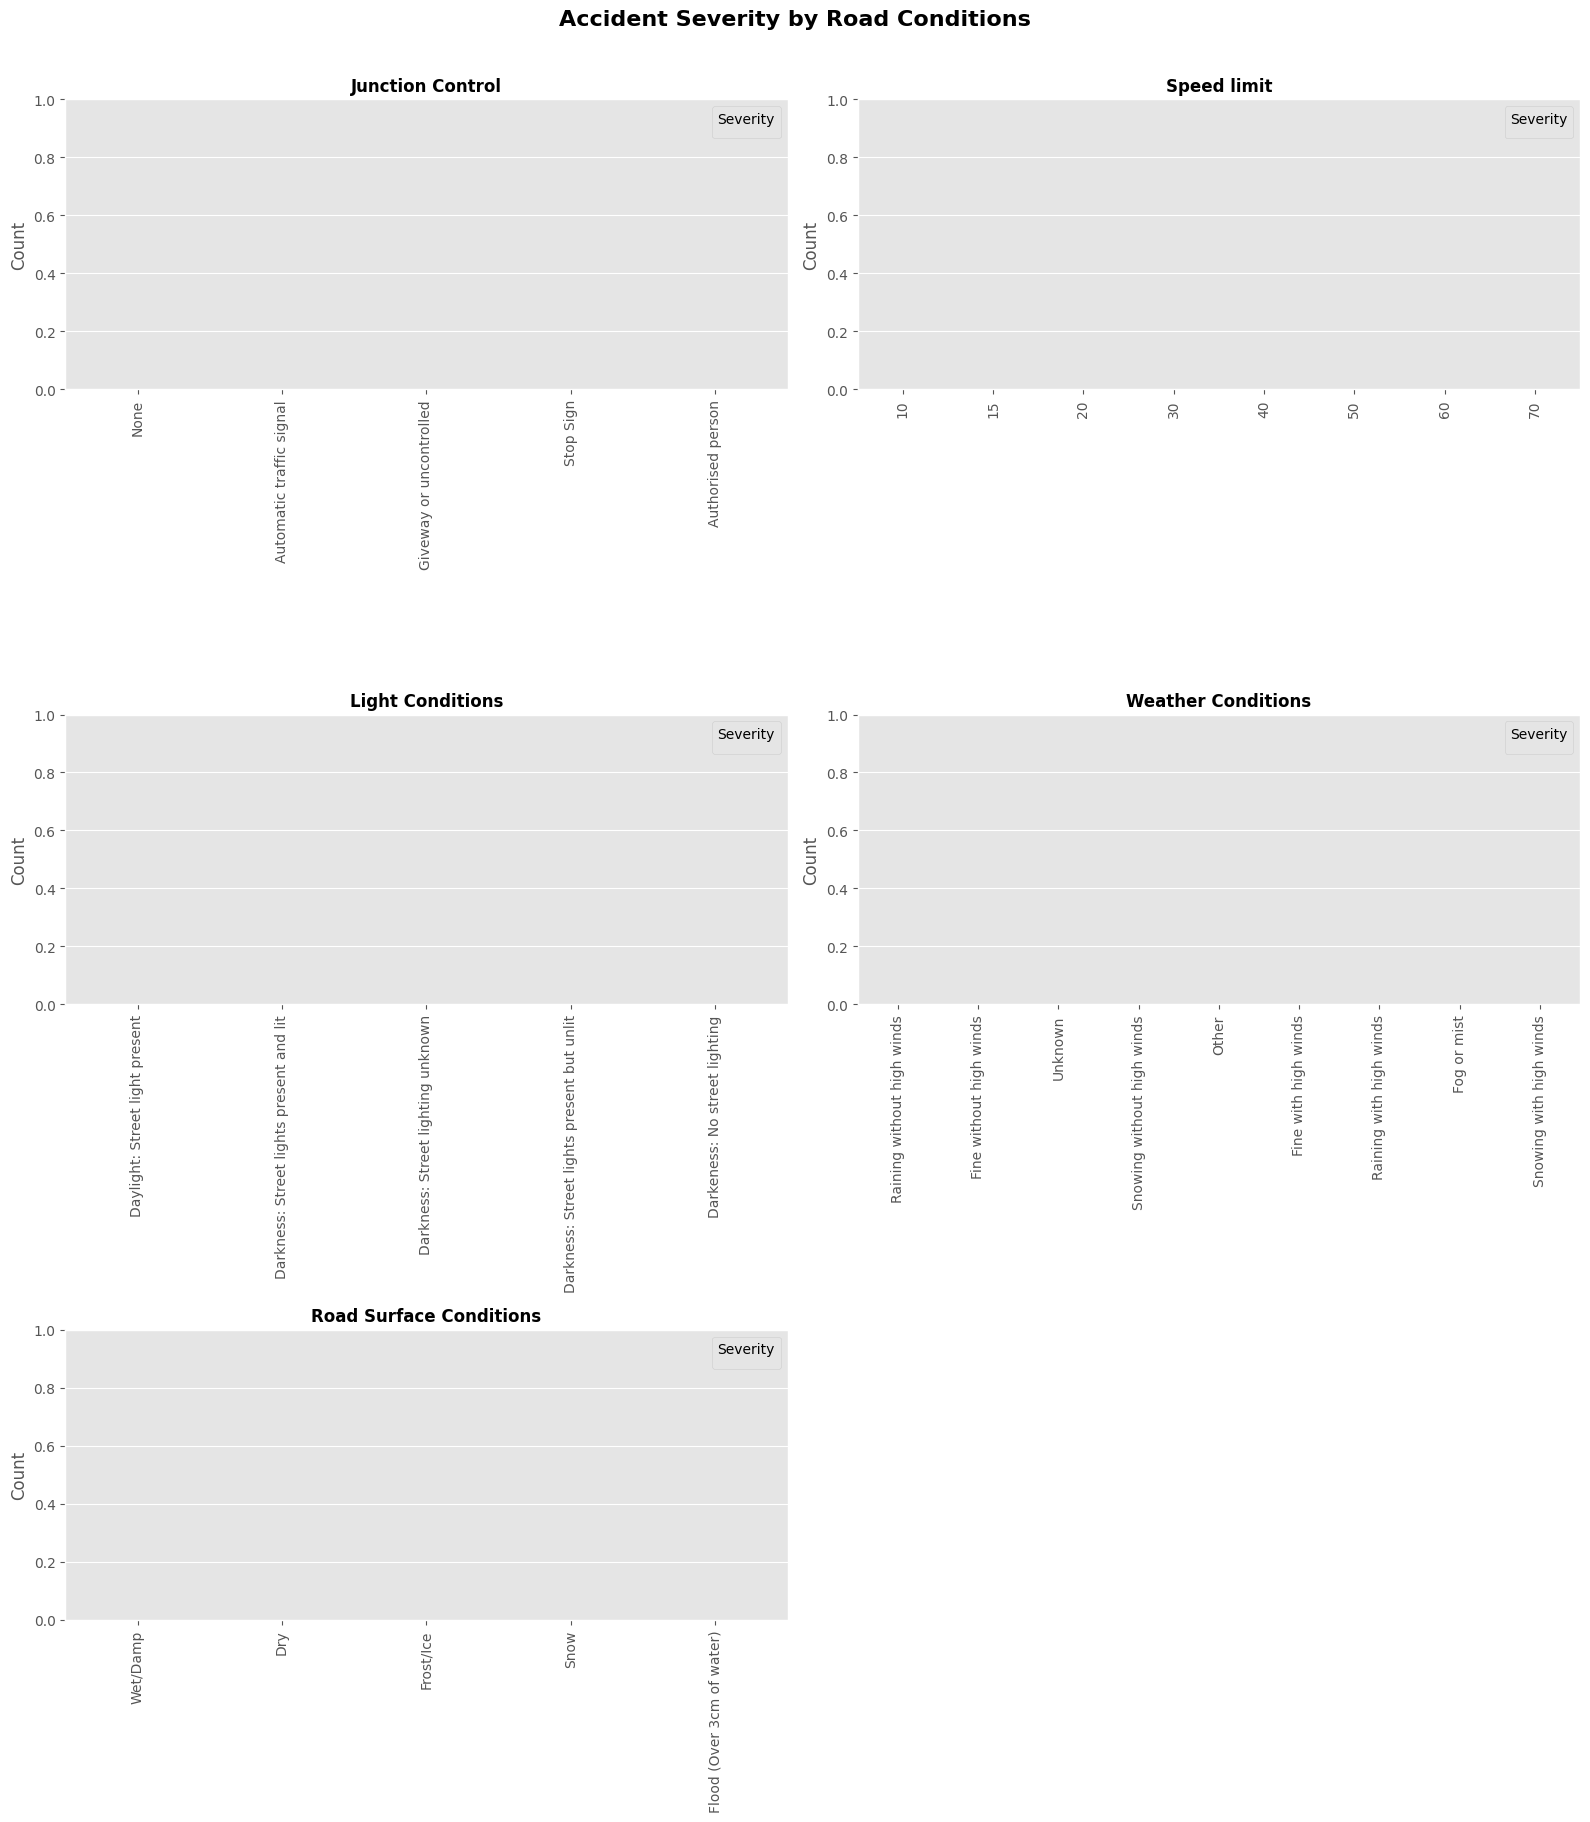

In [ ]:

features = ['Junction_Control', 'Speed_limit', 'Light_Conditions', 
            'Weather_Conditions', 'Road_Surface_Conditions']

severity_order = ['Fatal', 'Serious', 'Slight']
palette = {'Fatal': '#d62728', 'Serious': '#ff7f0e', 'Slight': '#2ca02c'}

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()

for i, col in enumerate(features):
    ax = axes[i]
    sns.countplot(
        data=df,
        x=col,
        hue='Accident_Severity',
        hue_order=severity_order,
        palette=palette,
        ax=ax
    )
    ax.set_title(col.replace('_', ' '), fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=90)
    ax.legend(title='Severity', loc='upper right')

axes[-1].set_visible(False)

plt.suptitle('Accident Severity by Road Conditions', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()